In [21]:
!pip install wordcloud

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud  # Changed 'Wordcloud' to 'wordcloud' - correct capitalization
from collections import Counter
import nltk  # Added missing import for nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [48]:
df=pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [49]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [51]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(415)

In [53]:
df.drop_duplicates(inplace=True)

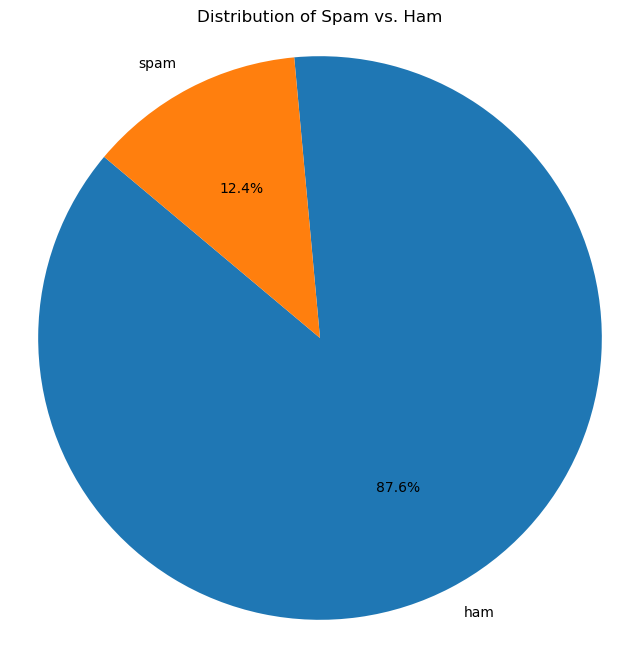

In [54]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Spam vs. Ham')
plt.axis('equal') 
plt.show()

In [55]:
le = LabelEncoder()
df['Category']=le.fit_transform(df['Category'])
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [56]:
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [57]:
df.to_csv("clean_spam.csv", index=False)

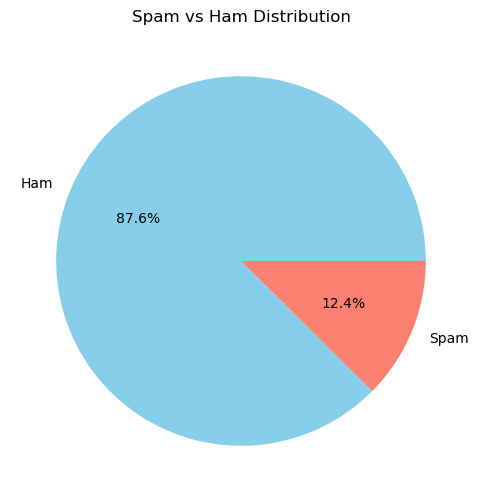

In [70]:
df['Category'].value_counts()

plt.figure(figsize=(6,6))

df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam'],
    colors=['skyblue','salmon']
)

plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

In [71]:
df['num_characters'] = df['Message'].apply(len)

df['num_words'] = df['Message'].apply(lambda x: len(x.split()))

df['num_sentences'] = df['Message'].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [72]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.104324,15.410704,1.969750
std,58.384729,11.118902,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,7.000000,1.000000
50%,61.000000,12.000000,1.000000
75%,118.000000,22.000000,2.000000
max,910.000000,171.000000,38.000000


In [73]:
df.groupby('Category')[['num_characters',
                        'num_words',
                        'num_sentences']].mean()

,num_characters,num_words,num_sentences
Category,,,
0,70.869796,14.239814,1.827724
1,137.118565,23.659906,2.970359


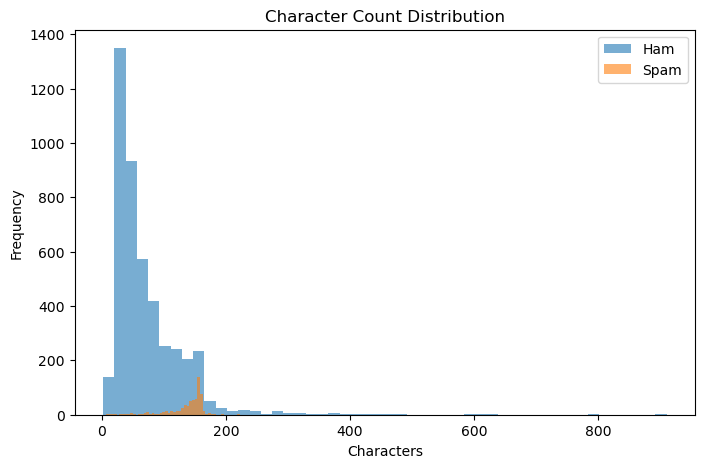

In [74]:
plt.figure(figsize=(8,5))

plt.hist(df[df['Category']==0]['num_characters'],
         bins=50,
         alpha=0.6,
         label="Ham")

plt.hist(df[df['Category']==1]['num_characters'],
         bins=50,
         alpha=0.6,
         label="Spam")

plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Character Count Distribution")
plt.legend()

plt.show()

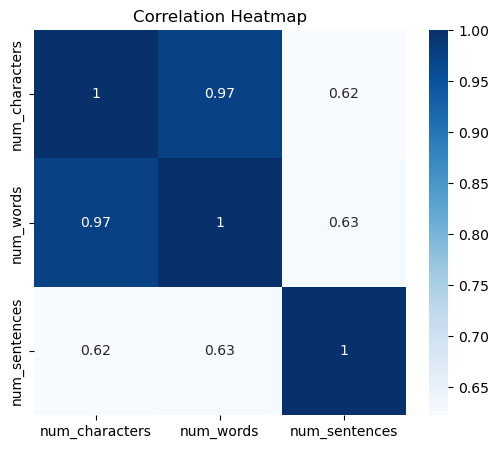

In [75]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['num_characters',
        'num_words',
        'num_sentences']].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

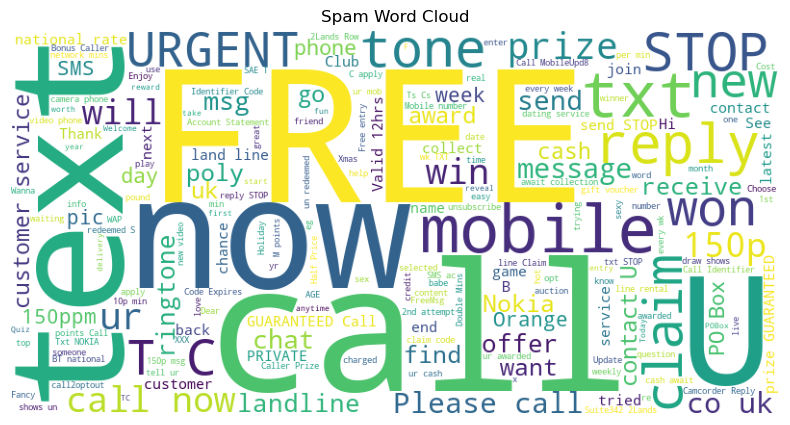

In [76]:
spam_text = " ".join(df[df['Category']==1]['Message'])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()

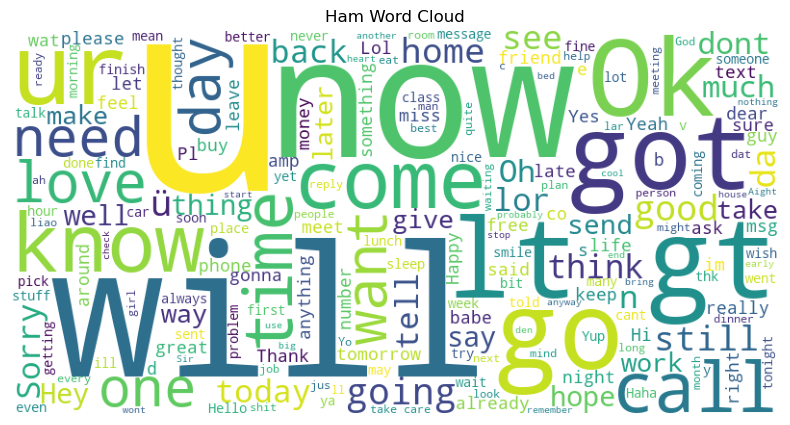

In [77]:
ham_text = " ".join(df[df['Category']==0]['Message'])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Ham Word Cloud")
plt.show()